# OFEV 24h ensemble event plots

Plot observed flood events above 400 m3/s and overlay the OFEV 24h ensemble forecasts.
Each model is drawn with a single color across all of its raw ensemble members, and the member values are connected through time.
Summary columns such as `Q_p25`, `Q_p50`, `Q_max`, and `Q_ctl` are ignored.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

notebook_dir = Path.cwd()
if (notebook_dir / "data").exists():
    BASE_DIR = notebook_dir
elif (notebook_dir.parent / "data").exists():
    BASE_DIR = notebook_dir.parent
else:
    BASE_DIR = notebook_dir

obs_path = BASE_DIR / "data/Data Fornisseurs/ARVE/2170_Abfluss_10-Min-Mittel_1999-01-01_2024-12-31.csv"
ofev_path = BASE_DIR / "outputs/OFEV_probabilistic/station2170_ensemble_wide.csv"
output_dir = BASE_DIR / "outputs/OFEV_probabilistic/LT_12h/event_timeseries"
output_dir.mkdir(parents=True, exist_ok=True)

FLOOD_THR = 400
LEAD_TIME_H = 12
member_cols = [f"Q_e{i:02d}" for i in range(1, 21)]


In [32]:
def get_flood_events(series, thr, gap_hours=12):
    mask = series > thr
    groups = (mask != mask.shift()).cumsum()

    raw_events = []
    for _, g in series[mask].groupby(groups):
        raw_events.append((g.index.min(), g.index.max()))

    if len(raw_events) == 0:
        return []

    merged = [raw_events[0]]
    for start, end in raw_events[1:]:
        prev_start, prev_end = merged[-1]
        gap = (start - prev_end).total_seconds() / 3600
        if gap <= gap_hours:
            merged[-1] = (prev_start, end)
        else:
            merged.append((start, end))

    return merged

obs = pd.read_csv(obs_path, sep=";", encoding="cp1252", skiprows=8)
obs.columns = obs.columns.str.strip()
obs["Zeitstempel"] = pd.to_datetime(obs["Zeitstempel"])
obs["Wert"] = pd.to_numeric(obs["Wert"], errors="coerce")
obs = obs[["Zeitstempel", "Wert"]].rename(columns={"Wert": "Q_obs"})
obs = obs.set_index("Zeitstempel")
obs_h = obs.resample("1h").mean()

ofev = pd.read_csv(ofev_path)
ofev.columns = ofev.columns.str.strip()
ofev["issue_time"] = pd.to_datetime(ofev["issue_time"])
ofev["valid_time"] = pd.to_datetime(ofev["valid_time"])
ofev["lead_time_h"] = pd.to_numeric(ofev["lead_time_h"], errors="coerce")
ofev_24 = ofev[np.round(ofev["lead_time_h"]) == LEAD_TIME_H].copy()
ofev_24 = ofev_24.sort_values(["model", "issue_time", "valid_time"])
ofev_24 = ofev_24[["model", "issue_time", "valid_time"] + member_cols].copy()

model_names = sorted(ofev_24["model"].dropna().unique())
cmap = plt.cm.get_cmap('tab20')
model_colors = dict(zip(model_names, cmap(np.linspace(0,1,len(model_names)))))
model_colors = dict(zip(model_names, plt.cm.turbo(np.linspace(0, 1, len(model_names)))))

events = get_flood_events(obs_h["Q_obs"], FLOOD_THR)
print(f"Found {len(events)} observed flood events above {FLOOD_THR} m3/s")
print(f"Found {len(model_names)} models in the 24h ensemble table: {', '.join(model_names)}")


Found 40 observed flood events above 400 m3/s
Found 5 models in the 24h ensemble table: C1E, C2E, COSMOE, ICH1, ICH2


C:\Users\simon\AppData\Local\Temp\ipykernel_18932\3688373477.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')


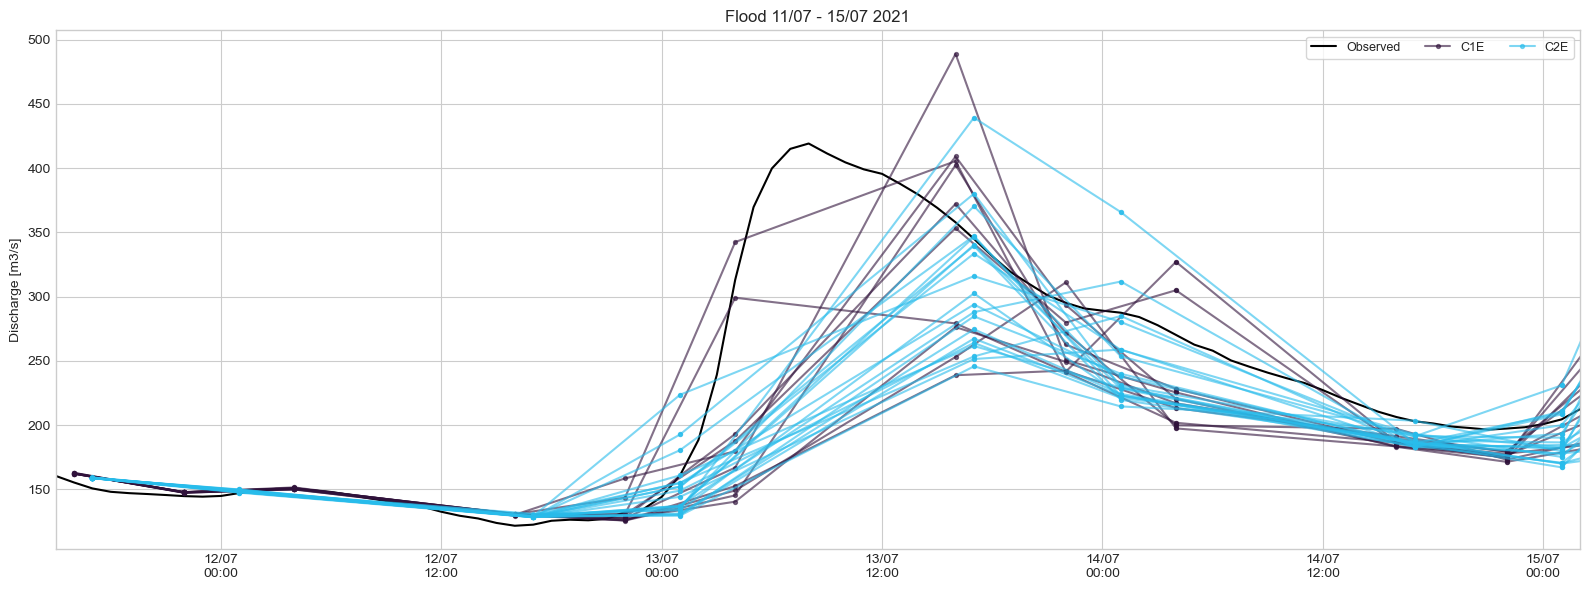

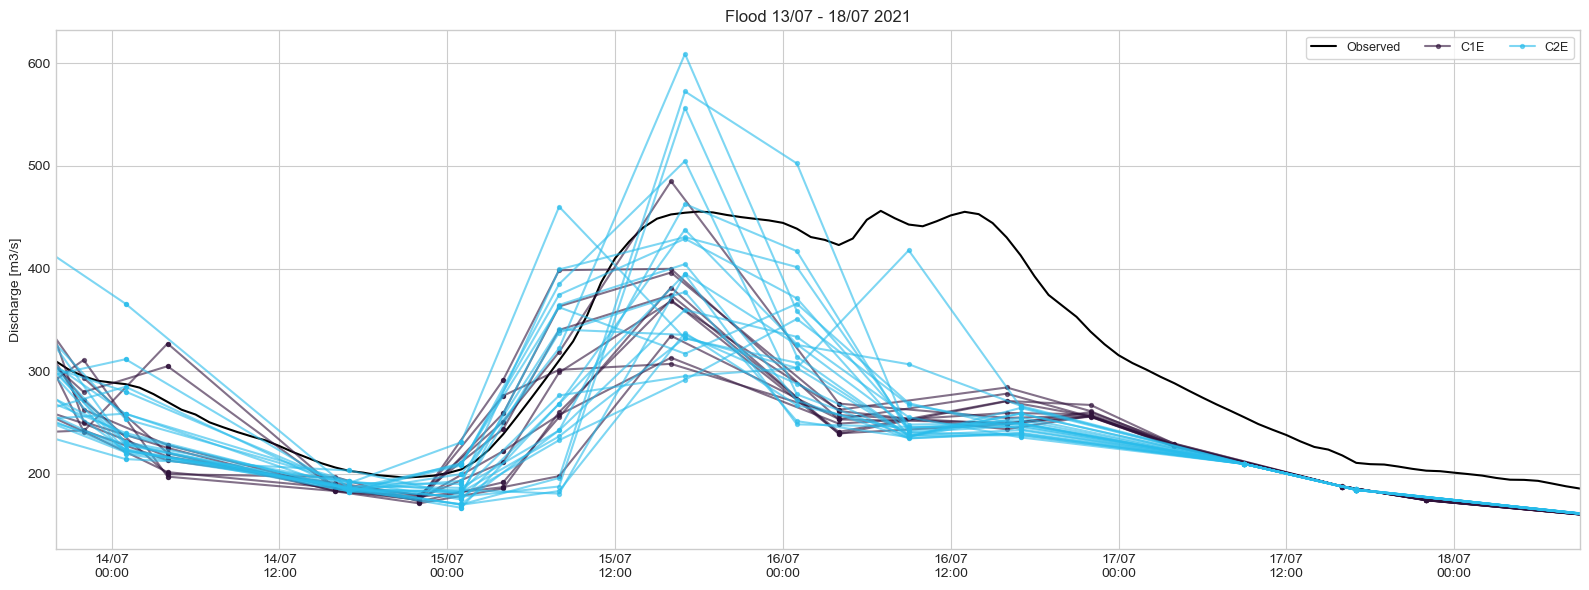

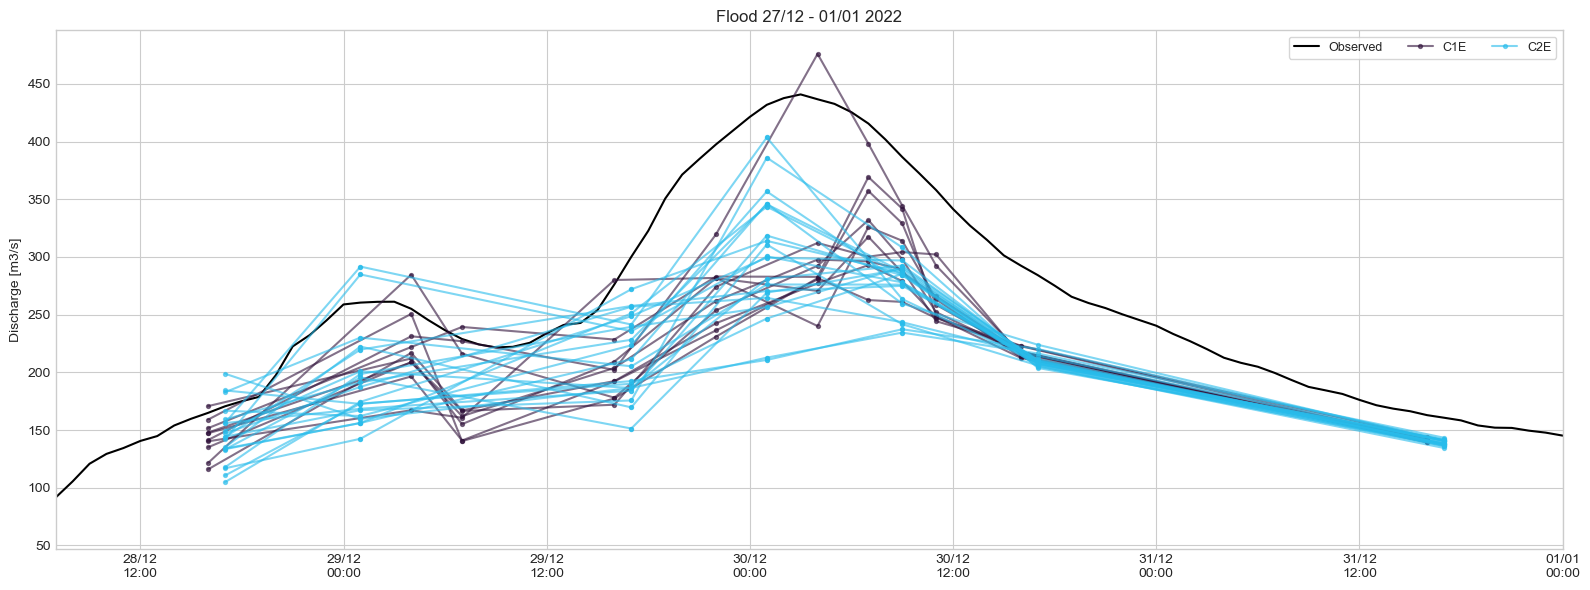

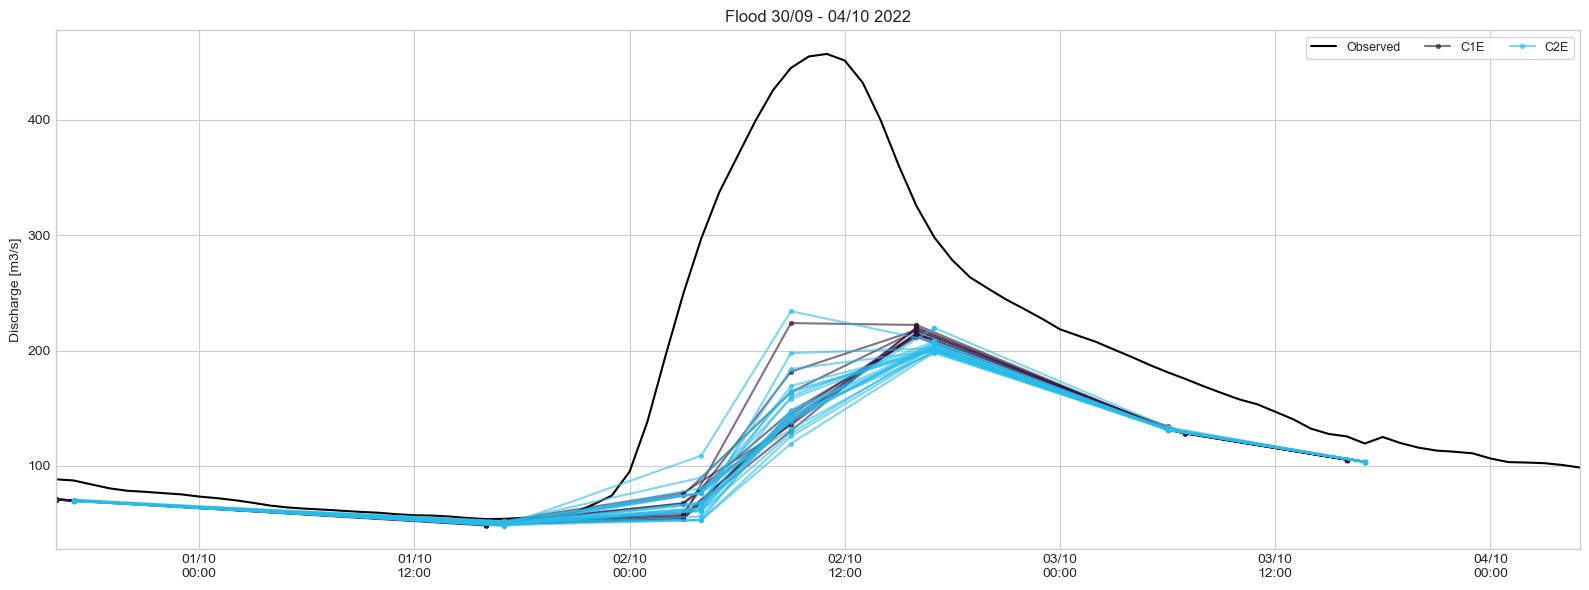

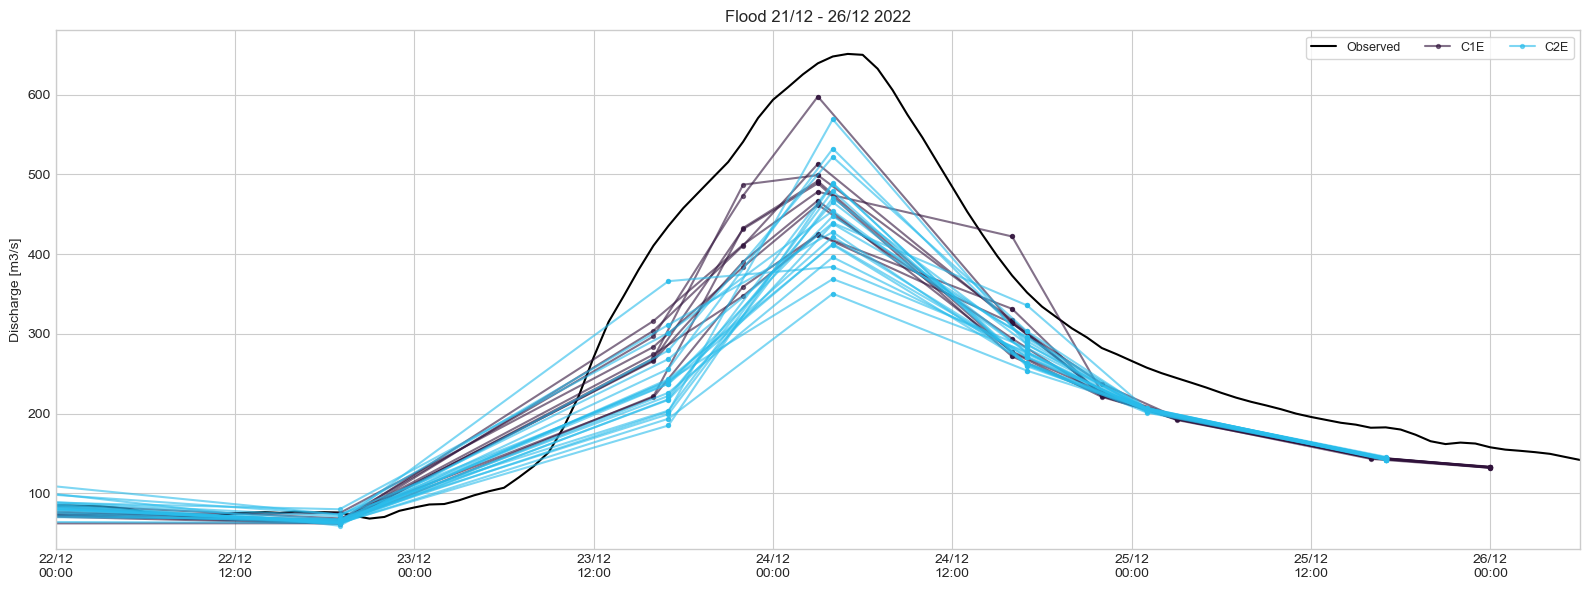

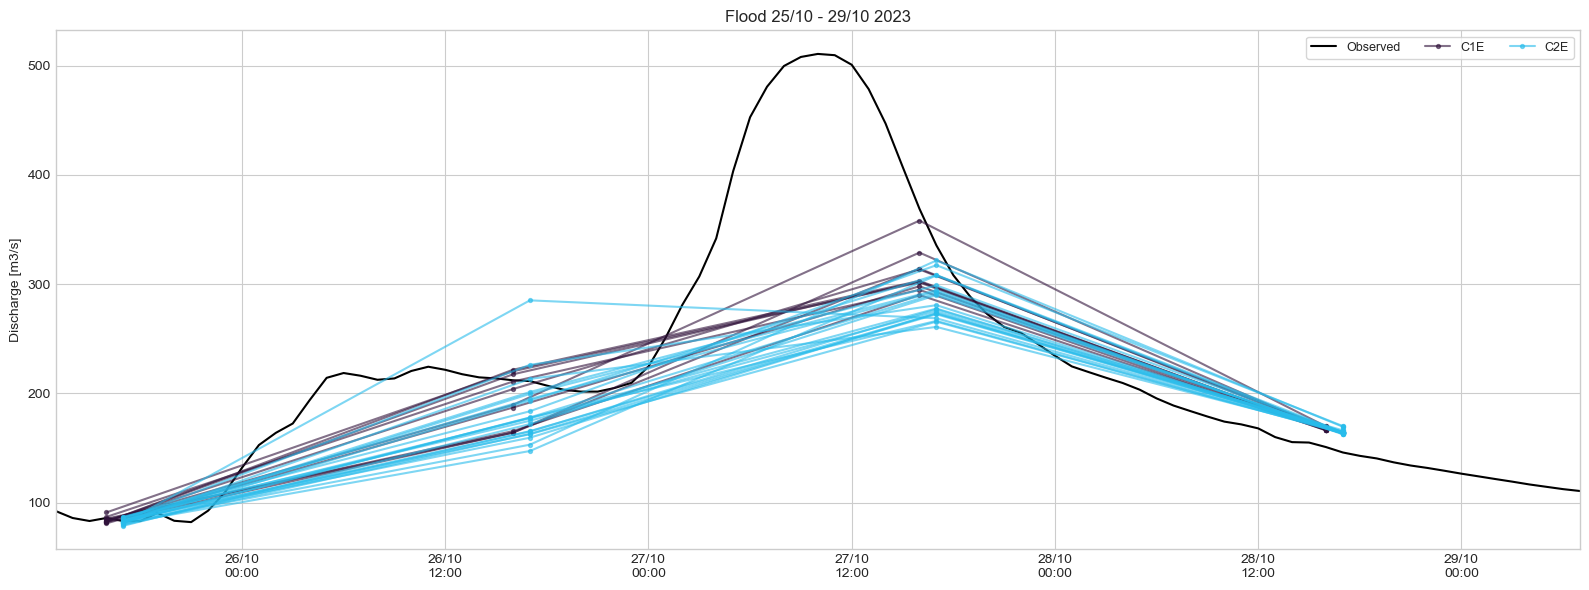

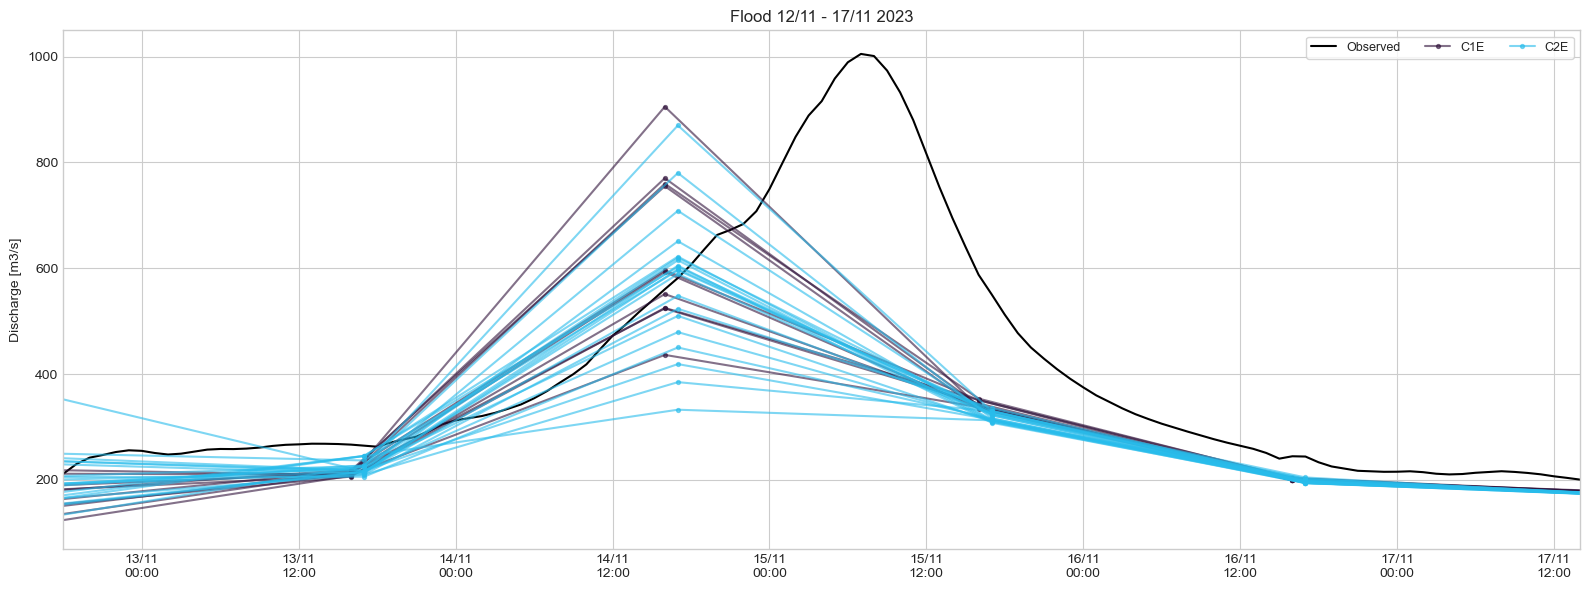

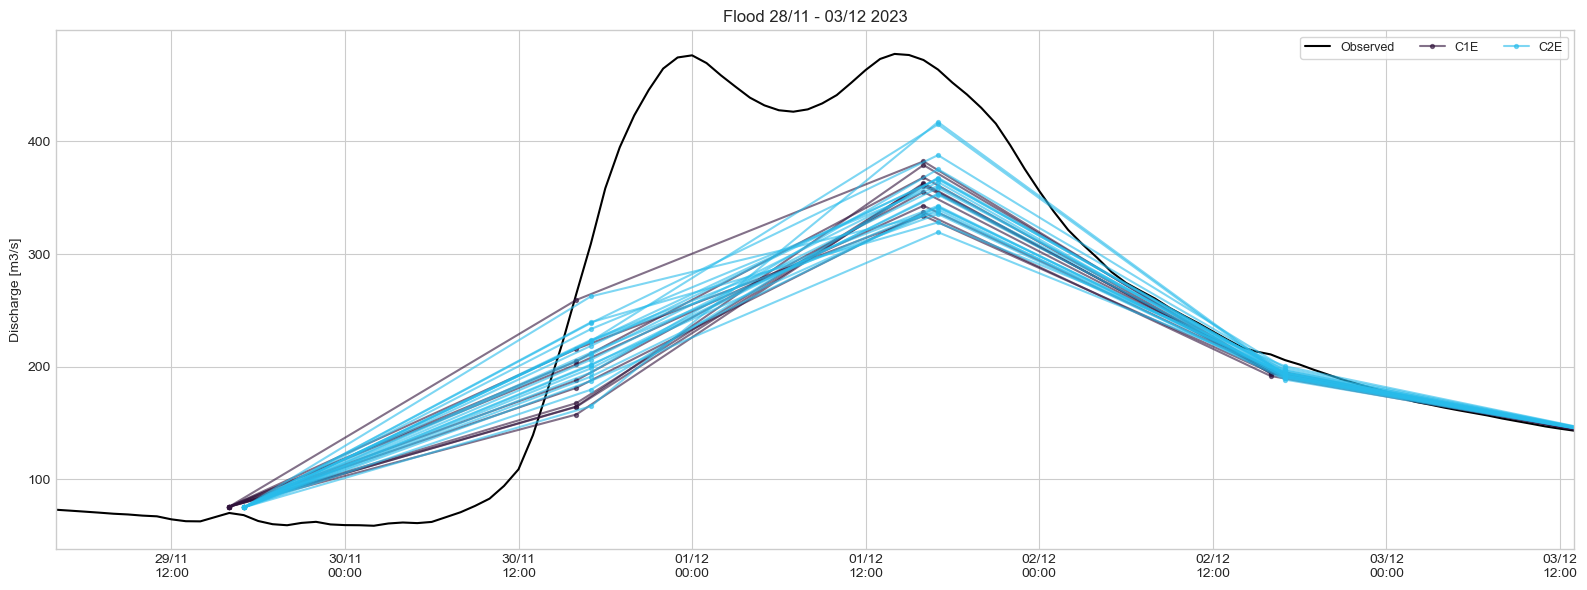

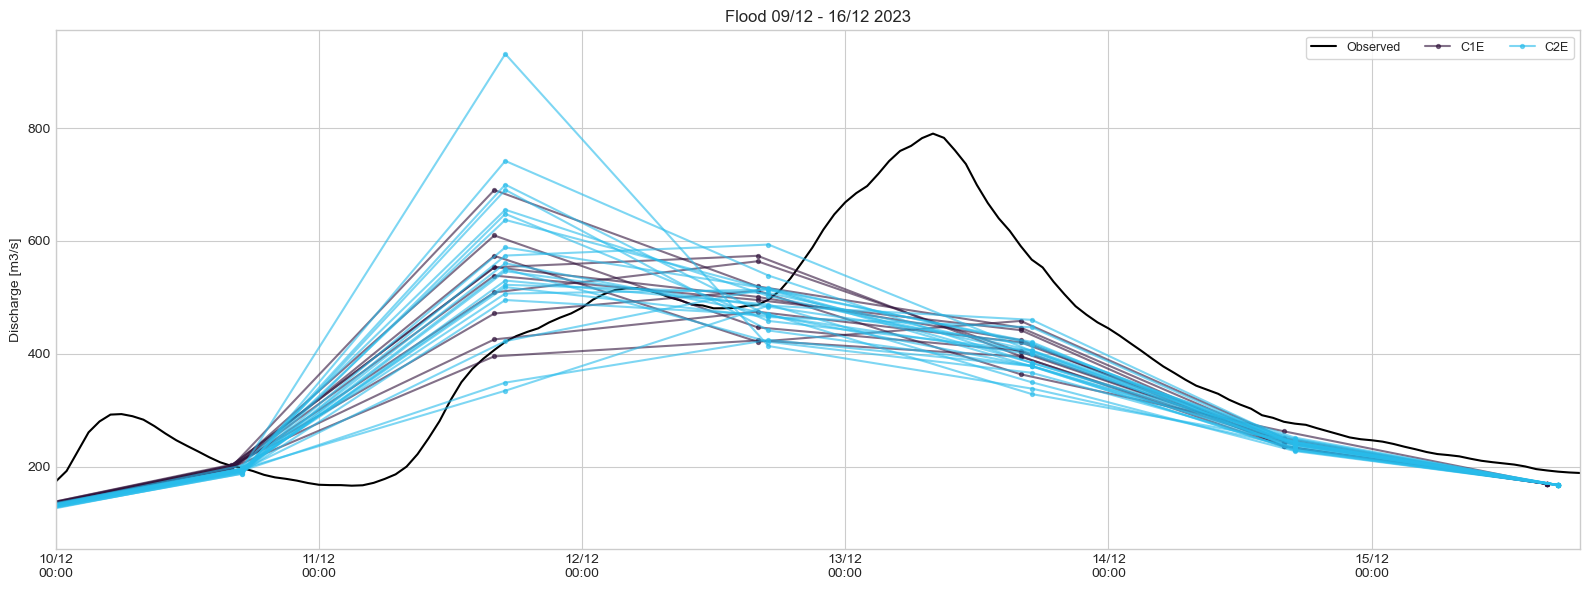

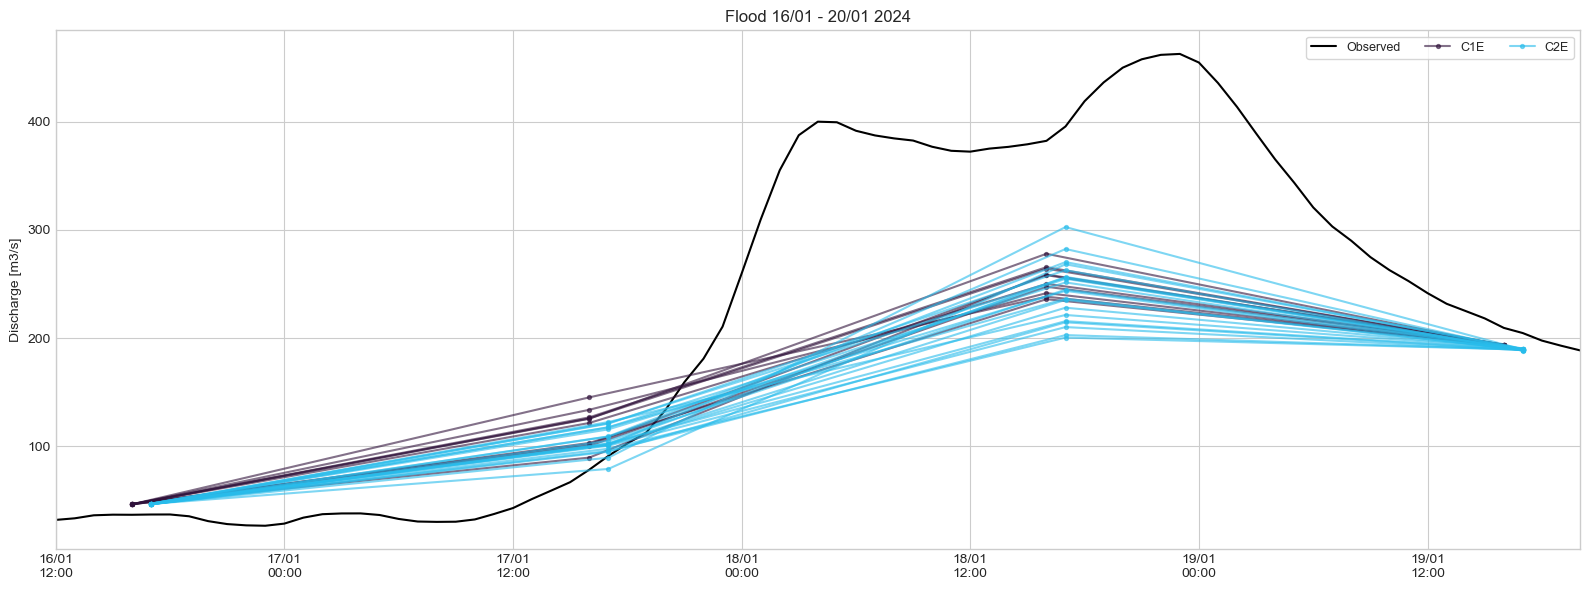

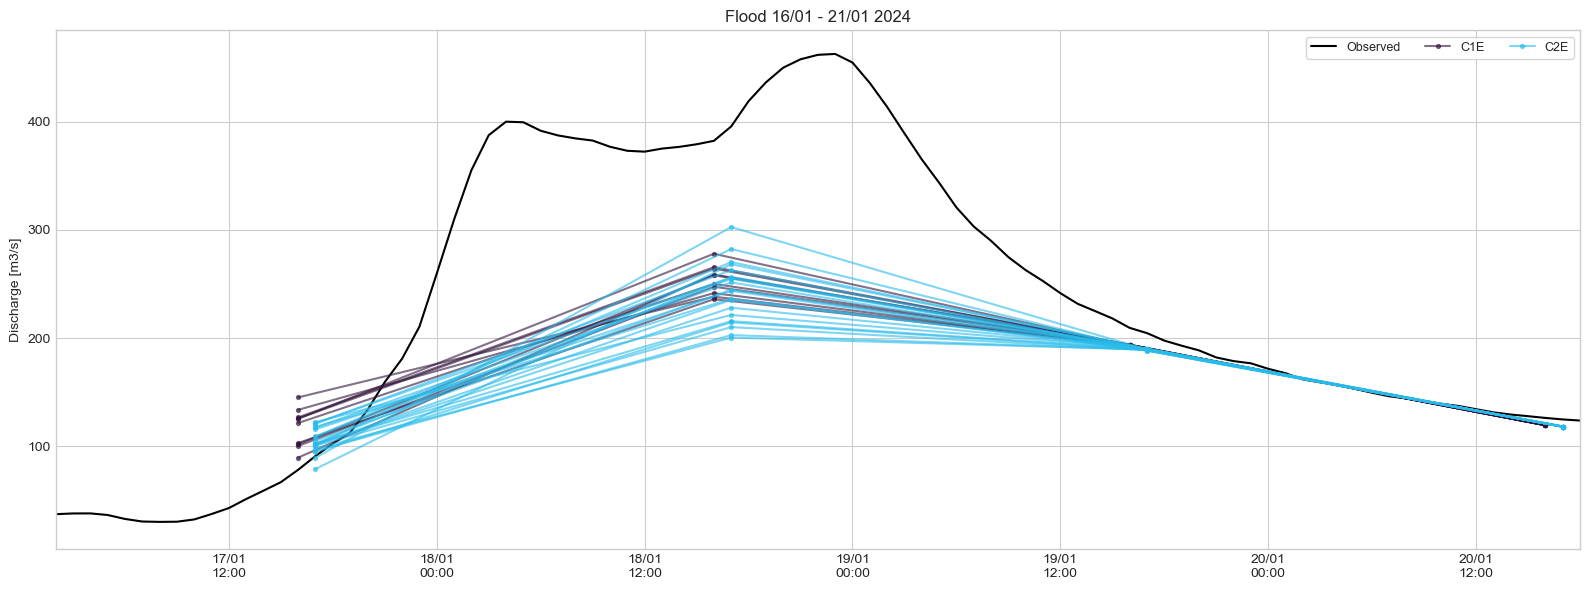

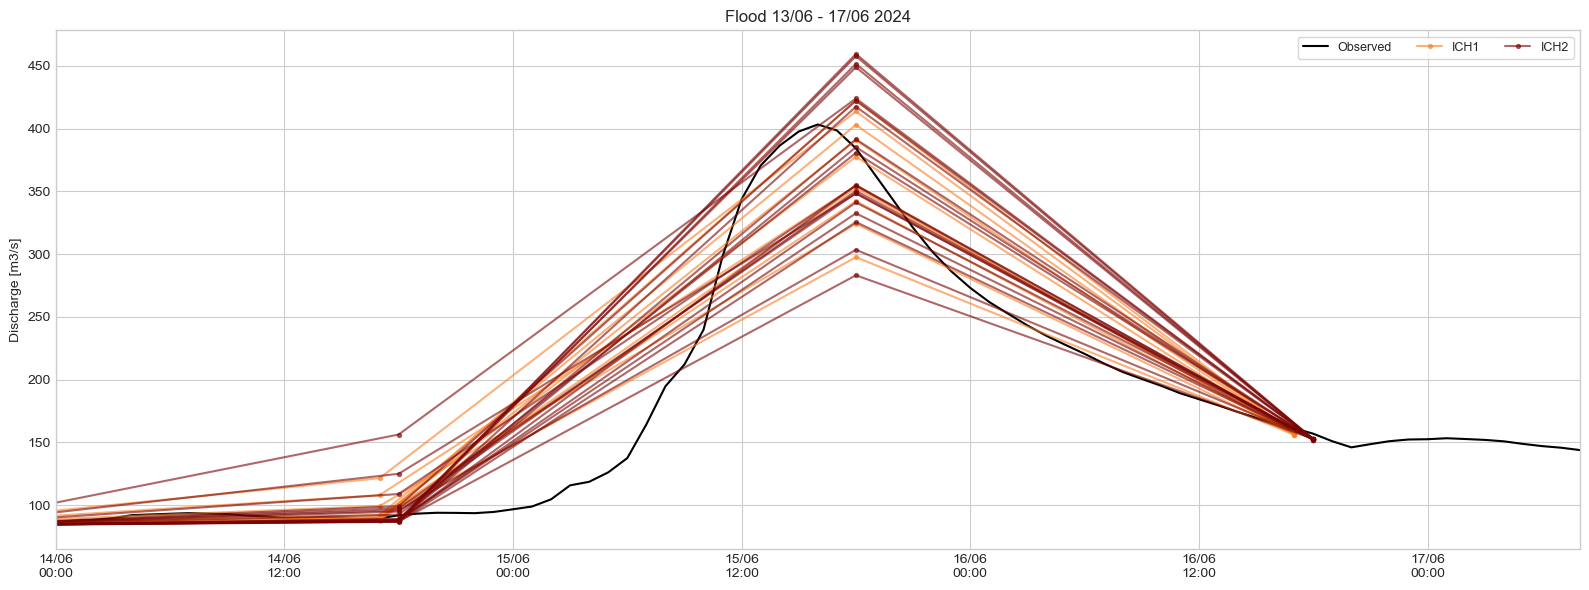

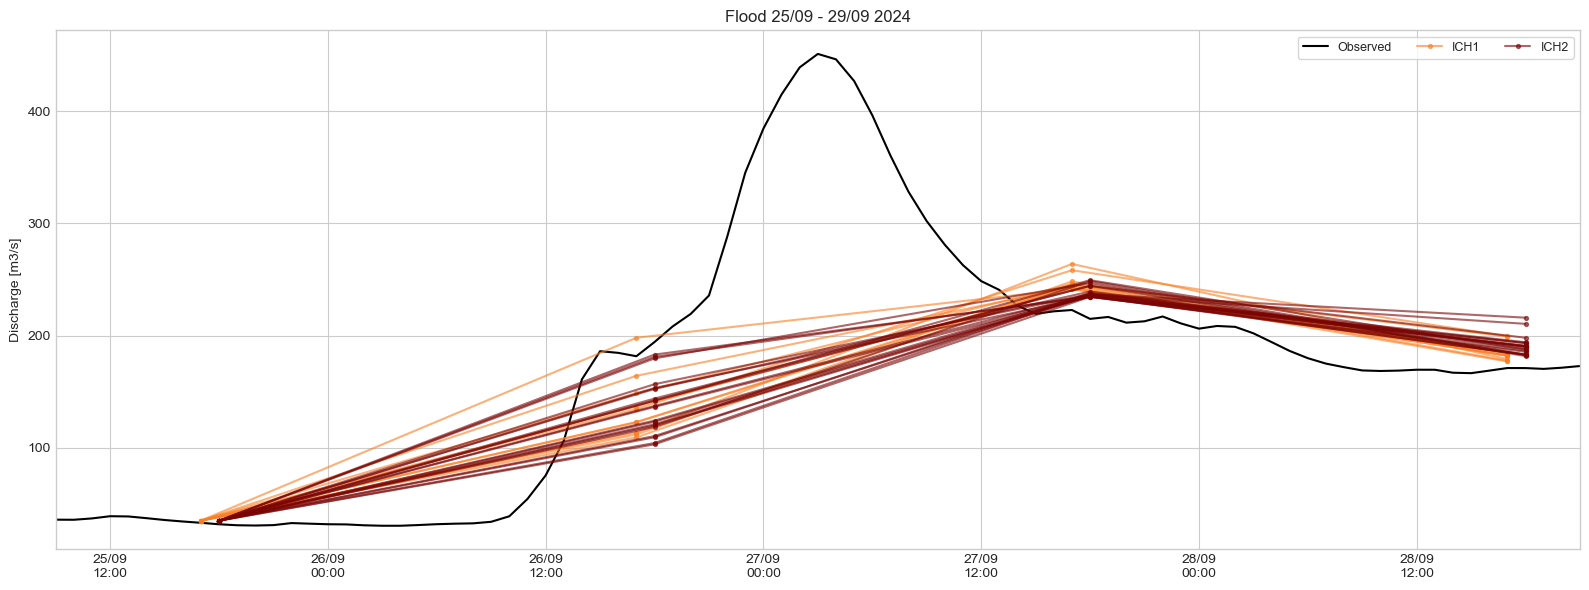

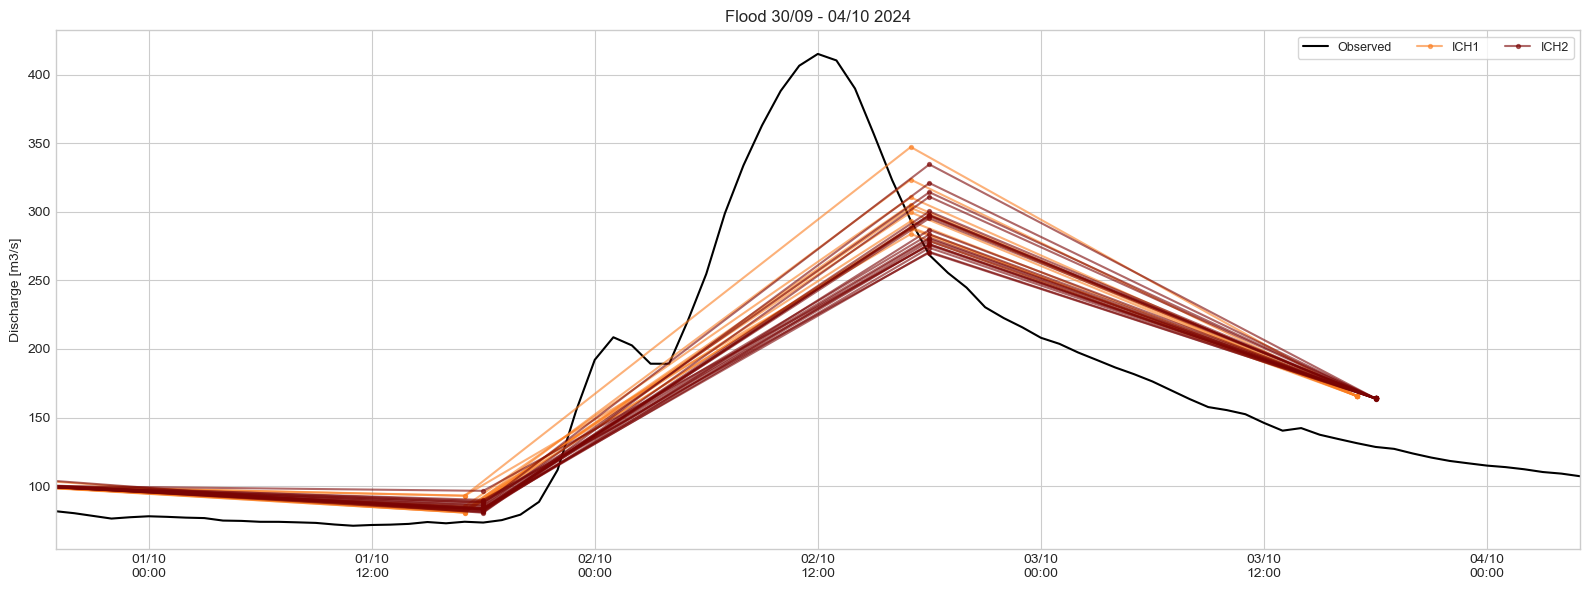

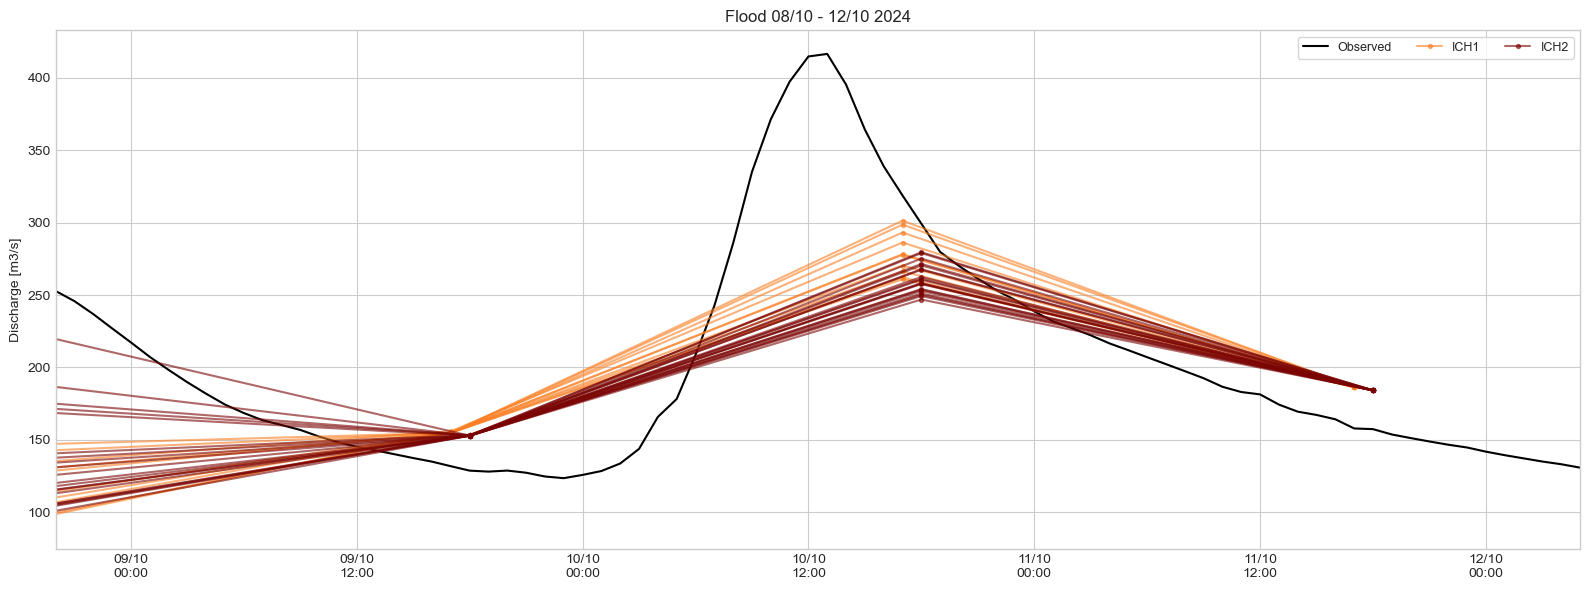

In [34]:
for i, (start, end) in enumerate(events, start=1):
    start_win = start - pd.Timedelta(days=2)
    end_win = end + pd.Timedelta(days=2)

    obs_win = obs_h.loc[start_win:end_win]
    pred_win = ofev_24.loc[(ofev_24["valid_time"] >= start_win) & (ofev_24["valid_time"] <= end_win)]

    if len(obs_win) == 0 or len(pred_win) == 0:
        continue

    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(obs_win.index, obs_win["Q_obs"], color="black", linewidth=1.5, label="Observed")

    for model in model_names:
        model_data = pred_win.loc[pred_win["model"] == model]
        if model_data.empty:
            continue

        color = model_colors[model]
        first_label = True

        for member in member_cols:
            member_data = (
                model_data[["issue_time", "valid_time", member]]
                .dropna()
                .sort_values(["valid_time", "issue_time"])
            )
            if member_data.empty:
                continue

            ax.plot(
                member_data["valid_time"],
                member_data[member],
                color=color,
                alpha=0.6,
                linewidth=1.5,
                marker="o",
                markersize=2.8,
                label=model if first_label else None,
            )
            first_label = False

    ax.set_xlim(start_win + pd.Timedelta(hours=8), end_win - pd.Timedelta(hours=8))
    ax.set_title(f"Flood {start_win.strftime('%d/%m')} - {end_win.strftime('%d/%m %Y')}")
    ax.set_ylabel("Discharge [m3/s]")
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d/%m\n%H:%M'))
    ax.legend(ncol=3, fontsize=9, frameon=True)
    fig.tight_layout()

    fname = f"flood_{start_win.strftime('%Y%m%d')}_{end_win.strftime('%Y%m%d')}_LT{LEAD_TIME_H}.png"
    fig.savefig(output_dir / fname, dpi=200)
    plt.show()
    plt.close(fig)
